In [1]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt

In [2]:
# Discrete-time system (constant velocity model)
A = np.array([[1, 1],
              [0, 1]])
B = np.array([[0],
              [1]])
C = np.array([[1, 0]])
D = np.array([[0]])

In [3]:
dt = 1.0
sys = ct.ss(A, B, C, D, dt)

In [4]:
# Noise covariances
Q = np.diag([0.01, 0.01])   # process noise
R = np.array([[0.1]])       # measurement noise

In [5]:
# Kalman gain
L, P, E = ct.dlqe(A, np.eye(2), C, Q, R)

In [6]:
# Simulation
N = 50
x = np.zeros((2, N))
x_hat = np.zeros((2, N))
y = np.zeros(N)

In [7]:
np.random.seed(0)

In [8]:
for k in range(N-1):
    # Process + measurement noise
    w = np.random.multivariate_normal([0, 0], Q)
    v = np.random.normal(0, np.sqrt(R[0,0]))

    # True system
    x[:, k+1] = A @ x[:, k] + w
    y[k] = (C @ x[:, k]).item() + v

    # Kalman prediction + correction
    x_hat[:, k+1] = A @ x_hat[:, k] + L @ (y[k] - C @ x_hat[:, k])

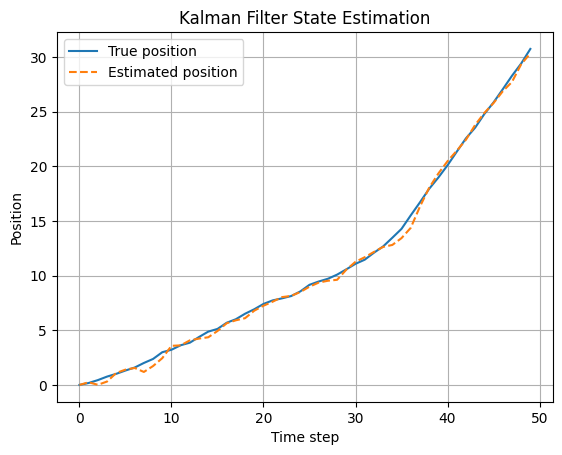

In [9]:
# Plot
plt.figure()
plt.plot(x[0, :], label="True position")
plt.plot(x_hat[0, :], '--', label="Estimated position")
plt.xlabel("Time step")
plt.ylabel("Position")
plt.legend()
plt.title("Kalman Filter State Estimation")
plt.grid()
plt.show()